# ============================================================
# Author: Mayur Deshmukh
# Title: 05_model_evaluation.ipynb
# Project: ML-Binary-Classifier-For-Stock-Price-rediction
# Purpose: Evaluation of baseline and tuned ML Models for Binary Classification
# Python Version: 3.11
# ============================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

output_dir = os.path.join("..", "..", "output")
print(f"Output directory: {os.path.abspath(output_dir)}")

Output directory: e:\Python_projects\Coursera\Classification-badge\s_n_p_classifier\model_files\output


In [2]:
# Load the pre-split, scaled feature matrices and binary target vectors
X_train = pd.read_csv(os.path.join(output_dir, "X_train.csv"))
X_test  = pd.read_csv(os.path.join(output_dir, "X_test.csv"))
y_train = pd.read_csv(os.path.join(output_dir, "y_train.csv")).squeeze()
y_test  = pd.read_csv(os.path.join(output_dir, "y_test.csv")).squeeze()

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}  |  y_test : {y_test.shape}")
print(f"\ny_test distribution:\n{y_test.value_counts()}")

X_train : (9330, 17)  |  X_test : (2770, 17)
y_train : (9330,)  |  y_test : (2770,)

y_test distribution:
target
1    1500
0    1270
Name: count, dtype: int64


In [3]:
# Load all 14 models saved by 04_model_predict.ipynb (7 baseline + 7 tuned)
# NOTE: Run 04_model_predict.ipynb completely first to generate the .joblib files
model_names = [
    "lr_baseline", "svc_baseline", "dt_baseline", "rf_baseline",
    "ada_baseline", "gbm_baseline", "xgb_baseline",
    "lr_best", "svc_best", "dt_best", "rf_best",
    "ada_best", "gbm_best", "xgb_best"
]

models = {}
for name in model_names:
    path = os.path.join(output_dir, f"{name}.joblib")
    try:
        models[name] = joblib.load(path)
        print(f"  Loaded : {name}")
    except FileNotFoundError:
        print(f"  [MISSING] {name} -- run 04_model_predict.ipynb first")

print(f"\nLoaded {len(models)} / {len(model_names)} models.")

  Loaded : lr_baseline
  Loaded : svc_baseline
  Loaded : dt_baseline
  Loaded : rf_baseline
  Loaded : ada_baseline
  Loaded : gbm_baseline
  Loaded : xgb_baseline
  Loaded : lr_best
  Loaded : svc_best
  Loaded : dt_best
  Loaded : rf_best
  Loaded : ada_best
  Loaded : gbm_best
  Loaded : xgb_best

Loaded 14 / 14 models.


In [4]:
# Helper: compute all 5 evaluation metrics for a given model on the test set
def evaluate_model(model, X_test, y_test, model_label):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    metrics = {
        "Model"    : model_label,
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1"       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score(y_test, y_prob), 4) if y_prob is not None else None,
    }
    return metrics, y_pred, y_prob

print("Helper function evaluate_model() defined.")

Helper function evaluate_model() defined.


In [5]:
print("=" * 60)
print("=== STEP 8: PERFORMANCE METRICS -- ALL MODELS ===")
print("=" * 60)

# Human-readable display labels for all 14 models
model_display_names = {
    "lr_baseline"  : "LR Baseline",
    "svc_baseline" : "SVM Baseline",
    "dt_baseline"  : "DT Baseline",
    "rf_baseline"  : "RF Baseline",
    "ada_baseline" : "AdaBoost Baseline",
    "gbm_baseline" : "GBM Baseline",
    "xgb_baseline" : "XGBoost Baseline",
    "lr_best"      : "LR Tuned",
    "svc_best"     : "SVM Tuned",
    "dt_best"      : "DT Tuned",
    "rf_best"      : "RF Tuned",
    "ada_best"     : "AdaBoost Tuned",
    "gbm_best"     : "GBM Tuned",
    "xgb_best"     : "XGBoost Tuned",
}

all_metrics = []   # list of metric dicts
all_preds   = {}   # {model_key: y_pred}
all_probs   = {}   # {model_key: y_prob}

for model_key, display_label in model_display_names.items():
    if model_key not in models:
        print(f"  [SKIP] {model_key} not loaded.")
        continue
    try:
        m, y_pred, y_prob = evaluate_model(models[model_key], X_test, y_test, display_label)
        all_metrics.append(m)
        all_preds[model_key] = y_pred
        all_probs[model_key] = y_prob
        print(f"  {display_label:<22} | Acc={m['Accuracy']:.4f}  "
              f"Prec={m['Precision']:.4f}  Rec={m['Recall']:.4f}  "
              f"F1={m['F1']:.4f}  AUC={m['ROC-AUC']}")
    except Exception as e:
        print(f"  [ERROR] {model_key}: {e}")

metrics_df = pd.DataFrame(all_metrics)
print(f"\nMetrics computed for {len(all_metrics)} models.")

=== STEP 8: PERFORMANCE METRICS -- ALL MODELS ===
  LR Baseline            | Acc=0.6690  Prec=0.6628  Rec=0.7913  F1=0.7214  AUC=0.7424
  SVM Baseline           | Acc=0.7079  Prec=0.6987  Rec=0.8100  F1=0.7502  AUC=0.7766
  DT Baseline            | Acc=0.6462  Prec=0.6667  Rec=0.6933  F1=0.6797  AUC=0.6419
  RF Baseline            | Acc=0.7144  Prec=0.7187  Rec=0.7767  F1=0.7466  AUC=0.788
  AdaBoost Baseline      | Acc=0.6646  Prec=0.6571  Rec=0.7960  F1=0.7199  AUC=0.7545
  GBM Baseline           | Acc=0.7130  Prec=0.7140  Rec=0.7840  F1=0.7474  AUC=0.7928
  XGBoost Baseline       | Acc=0.7296  Prec=0.7226  Rec=0.8127  F1=0.7650  AUC=0.8066
  LR Tuned               | Acc=0.8610  Prec=0.8535  Rec=0.8973  F1=0.8749  AUC=0.9354
  SVM Tuned              | Acc=0.8549  Prec=0.8607  Rec=0.8733  F1=0.8670  AUC=0.9316
  DT Tuned               | Acc=0.6848  Prec=0.7161  Rec=0.6927  F1=0.7042  AUC=0.7498
  RF Tuned               | Acc=0.7184  Prec=0.7190  Rec=0.7880  F1=0.7519  AUC=0.795
  AdaB

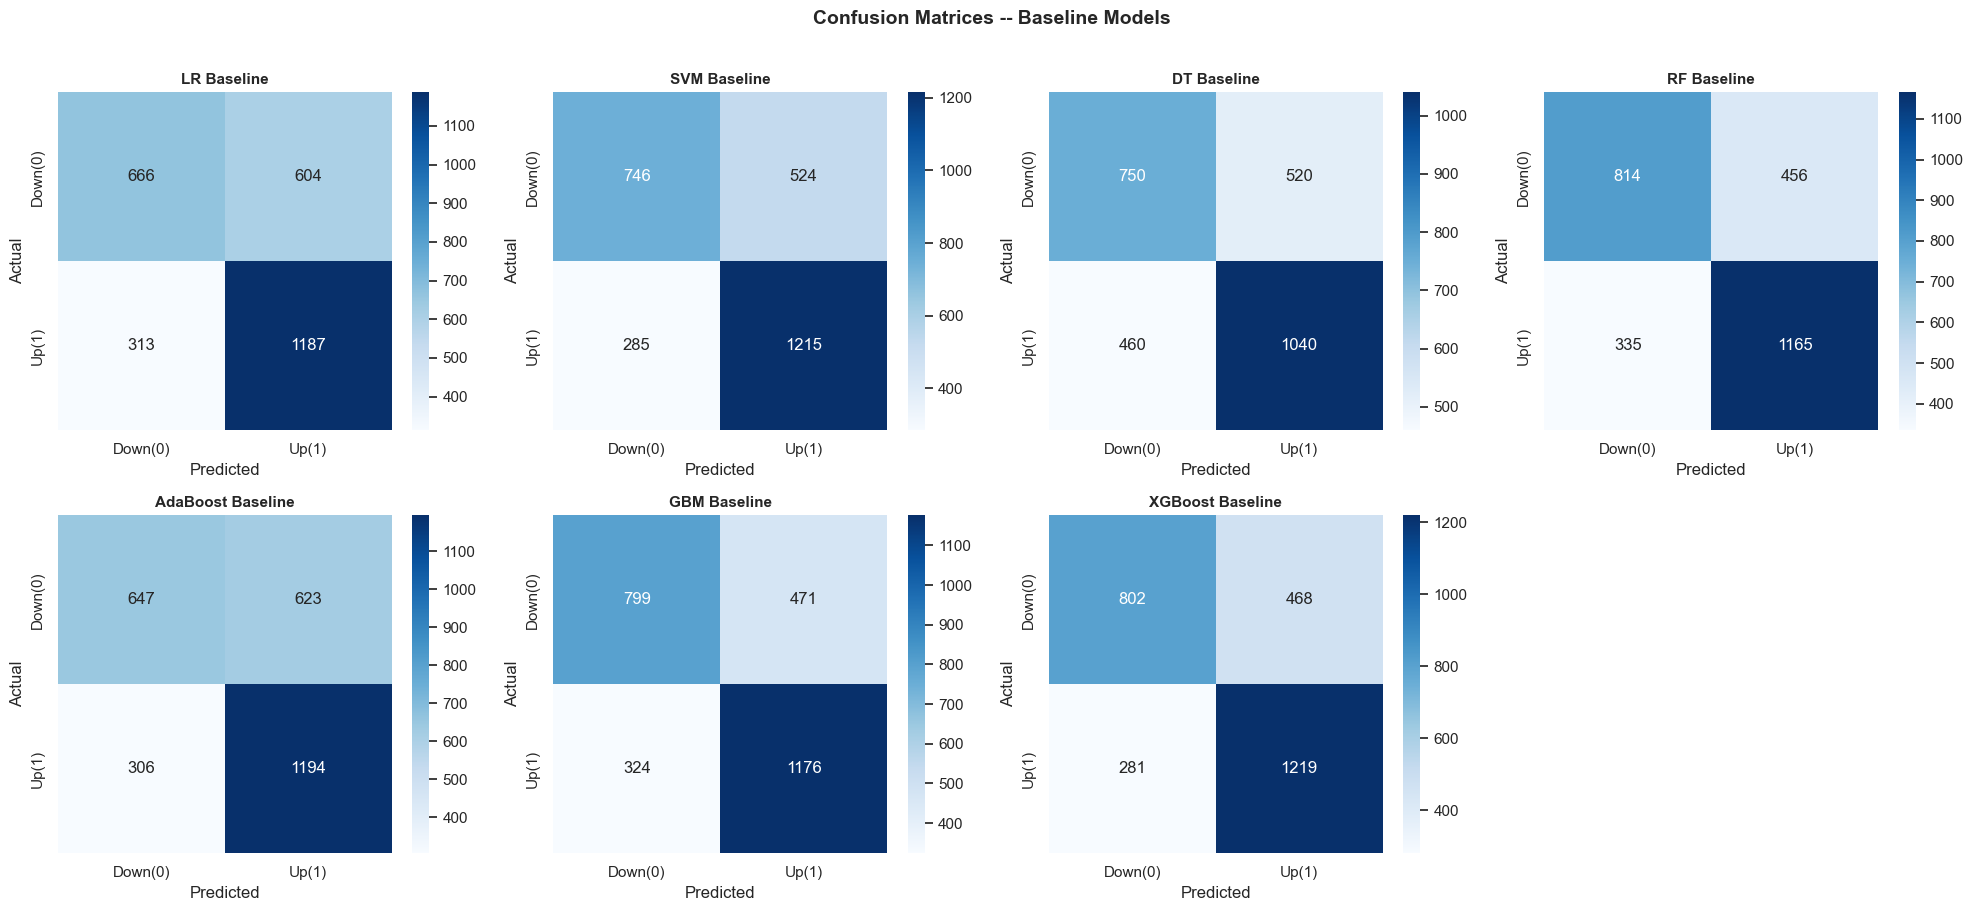

Saved: ..\..\output\eval_confusion_matrices_baseline.png


In [6]:
# Plot confusion matrices for all 7 BASELINE models in a 2x4 subplot grid
baseline_keys = ["lr_baseline", "svc_baseline", "dt_baseline", "rf_baseline",
                  "ada_baseline", "gbm_baseline", "xgb_baseline"]
try:
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    axes = axes.flatten()
    for idx, key in enumerate(baseline_keys):
        if key not in all_preds:
            axes[idx].set_visible(False)
            continue
        cm = confusion_matrix(y_test, all_preds[key])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx],
                    xticklabels=["Down(0)", "Up(1)"],
                    yticklabels=["Down(0)", "Up(1)"])
        axes[idx].set_title(model_display_names[key], fontsize=11, fontweight="bold")
        axes[idx].set_xlabel("Predicted")
        axes[idx].set_ylabel("Actual")
    axes[-1].set_visible(False)   # hide unused 8th subplot
    fig.suptitle("Confusion Matrices -- Baseline Models", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    save_path = os.path.join(output_dir, "eval_confusion_matrices_baseline.png")
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
except Exception as e:
    print(f"[ERROR] Baseline confusion matrix plot failed: {e}")

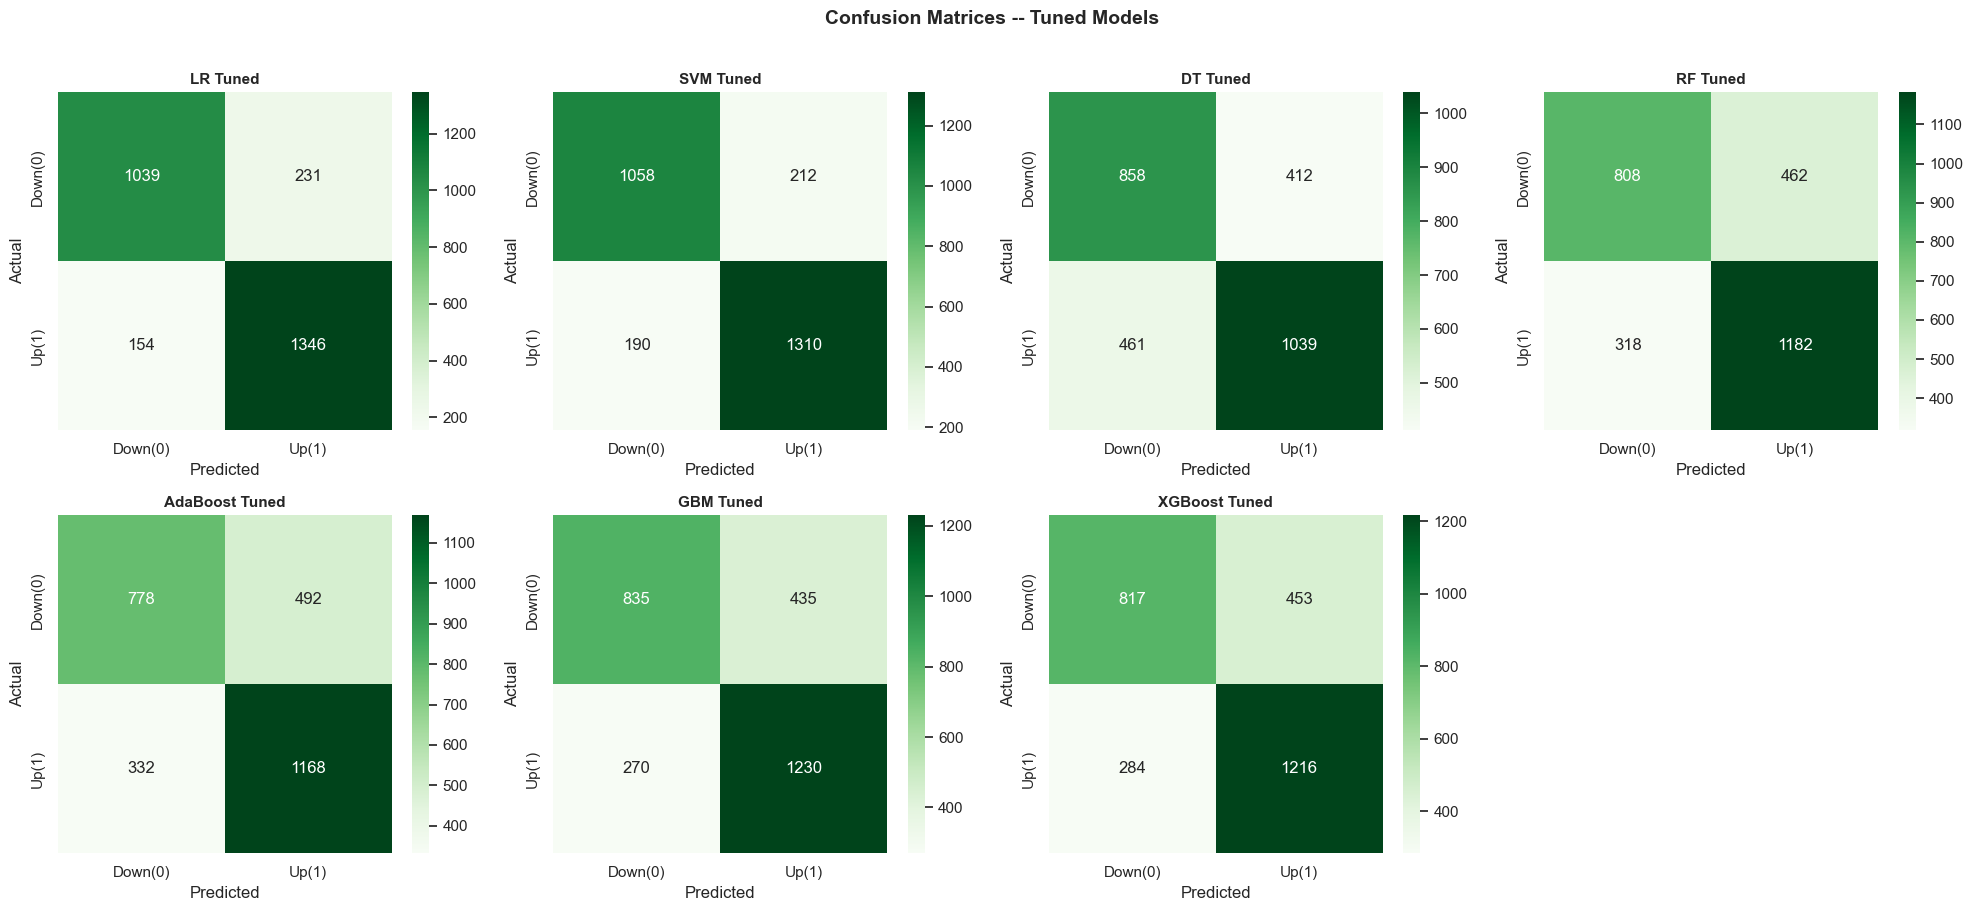

Saved: ..\..\output\eval_confusion_matrices_tuned.png


In [7]:
# Plot confusion matrices for all 7 TUNED models in a 2x4 subplot grid
tuned_keys = ["lr_best", "svc_best", "dt_best", "rf_best",
               "ada_best", "gbm_best", "xgb_best"]
try:
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    axes = axes.flatten()
    for idx, key in enumerate(tuned_keys):
        if key not in all_preds:
            axes[idx].set_visible(False)
            continue
        cm = confusion_matrix(y_test, all_preds[key])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=axes[idx],
                    xticklabels=["Down(0)", "Up(1)"],
                    yticklabels=["Down(0)", "Up(1)"])
        axes[idx].set_title(model_display_names[key], fontsize=11, fontweight="bold")
        axes[idx].set_xlabel("Predicted")
        axes[idx].set_ylabel("Actual")
    axes[-1].set_visible(False)
    fig.suptitle("Confusion Matrices -- Tuned Models", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    save_path = os.path.join(output_dir, "eval_confusion_matrices_tuned.png")
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
except Exception as e:
    print(f"[ERROR] Tuned confusion matrix plot failed: {e}")

In [8]:
print("=" * 60)
print("=== TUNED MODELS -- COMPARISON SUMMARY TABLE ===")
print("=" * 60)

# Filter for tuned models only and sort by ROC-AUC descending
tuned_label_set = {model_display_names[k] for k in tuned_keys}
tuned_df = (
    metrics_df[metrics_df["Model"].isin(tuned_label_set)]
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)
tuned_df.index = tuned_df.index + 1
tuned_df.index.name = "Rank"

# Highlight the best value in each metric column
styled = (
    tuned_df.style
    .highlight_max(subset=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
                   color="#d4f1c5")
    .format({"Accuracy": "{:.4f}", "Precision": "{:.4f}",
              "Recall": "{:.4f}", "F1": "{:.4f}", "ROC-AUC": "{:.4f}"})
    .set_caption("Tuned Models -- Test Set Performance (sorted by ROC-AUC descending)")
)
display(styled)

# Save comparison table to CSV
csv_path = os.path.join(output_dir, "eval_model_comparison.csv")
tuned_df.to_csv(csv_path)
print(f"\nSaved comparison table: {csv_path}")

=== TUNED MODELS -- COMPARISON SUMMARY TABLE ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
Rank,,,,,,
1,LR Tuned,0.8610,0.8535,0.8973,0.8749,0.9354
2,SVM Tuned,0.8549,0.8607,0.8733,0.8670,0.9316
3,GBM Tuned,0.7455,0.7387,0.8200,0.7773,0.8215
4,XGBoost Tuned,0.7339,0.7286,0.8107,0.7674,0.8133
5,RF Tuned,0.7184,0.7190,0.7880,0.7519,0.7950
6,AdaBoost Tuned,0.7025,0.7036,0.7787,0.7392,0.7736
7,DT Tuned,0.6848,0.7161,0.6927,0.7042,0.7498



Saved comparison table: ..\..\output\eval_model_comparison.csv


In [19]:
print("=" * 60)
print("=== BASELINE vs TUNED -- METRIC DELTA TABLE ===")
print("=" * 60)

# Build delta table: tuning gain/loss per algorithm and metric
algo_map = [
    ("LR Baseline",       "LR Tuned"),
    ("SVM Baseline",      "SVM Tuned"),
    ("DT Baseline",       "DT Tuned"),
    ("RF Baseline",       "RF Tuned"),
    ("AdaBoost Baseline", "AdaBoost Tuned"),
    ("GBM Baseline",      "GBM Tuned"),
    ("XGBoost Baseline",  "XGBoost Tuned"),
]

rows = []
for base_label, tuned_label in algo_map:
    base_row  = metrics_df[metrics_df["Model"] == base_label]
    tuned_row = metrics_df[metrics_df["Model"] == tuned_label]
    if base_row.empty or tuned_row.empty:
        continue
    b = base_row.iloc[0]
    t = tuned_row.iloc[0]
    algo = base_label.replace(" Baseline", "")
    for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
        rows.append({
            "Algorithm": algo,
            "Metric"   : metric,
            "Baseline" : b[metric],
            "Tuned"    : t[metric],
            "Delta"    : round(t[metric] - b[metric], 4)
        })

bvt_df = pd.DataFrame(rows)

def color_delta(val):
    color = "green" if val > 0 else ("red" if val < 0 else "black")
    return f"color: {color}"

styled_bvt = (bvt_df.style.map(color_delta, subset=["Delta"])
    .format({"Baseline": "{:.4f}", "Tuned": "{:.4f}", "Delta": "{:+.4f}"})
    .set_caption("Baseline vs Tuned -- Metric Delta per Algorithm")
)
display(styled_bvt)

=== BASELINE vs TUNED -- METRIC DELTA TABLE ===


,Algorithm,Metric,Baseline,Tuned,Delta
0,LR,Accuracy,0.6690,0.8610,+0.1920
1,LR,Precision,0.6628,0.8535,+0.1907
2,LR,Recall,0.7913,0.8973,+0.1060
3,LR,F1,0.7214,0.8749,+0.1535
4,LR,ROC-AUC,0.7424,0.9354,+0.1930
5,SVM,Accuracy,0.7079,0.8549,+0.1470
6,SVM,Precision,0.6987,0.8607,+0.1620
7,SVM,Recall,0.8100,0.8733,+0.0633
8,SVM,F1,0.7502,0.8670,+0.1168
9,SVM,ROC-AUC,0.7766,0.9316,+0.1550


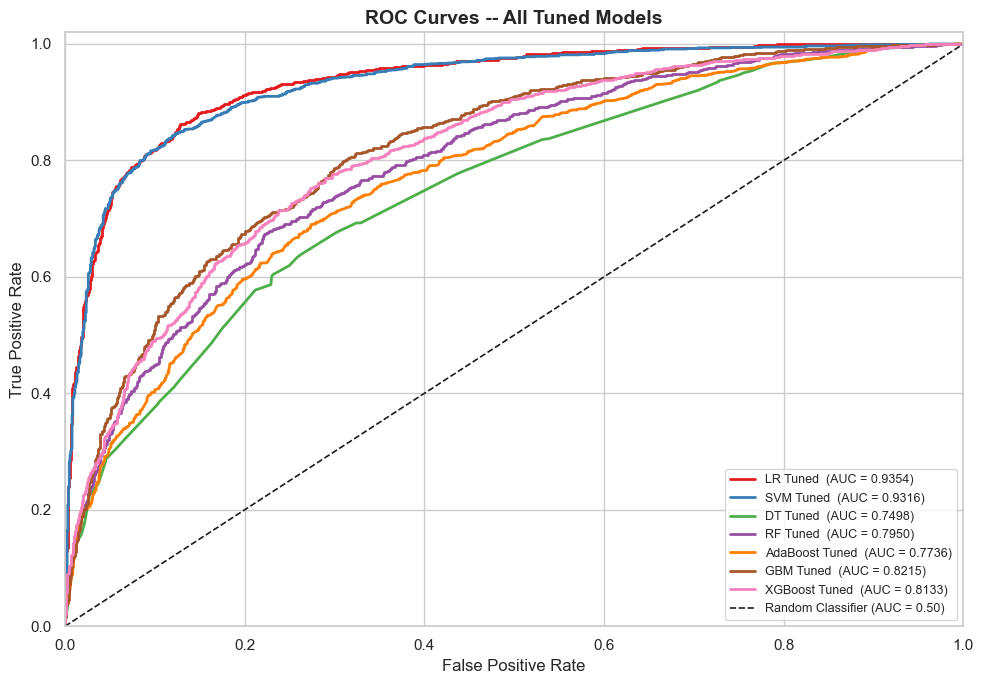

Saved: ..\..\output\eval_roc_curves_all_models.png


In [20]:
# Overlay ROC curves for all 7 tuned models on a single plot for direct comparison
try:
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
              "#ff7f00", "#a65628", "#f781bf"]
    for idx, key in enumerate(tuned_keys):
        if key not in all_probs or all_probs[key] is None:
            continue
        fpr, tpr, _ = roc_curve(y_test, all_probs[key])
        roc_auc_val = auc(fpr, tpr)
        label = f"{model_display_names[key]}  (AUC = {roc_auc_val:.4f})"
        ax.plot(fpr, tpr, color=colors[idx % len(colors)], lw=2, label=label)
    ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random Classifier (AUC = 0.50)")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title("ROC Curves -- All Tuned Models", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    save_path = os.path.join(output_dir, "eval_roc_curves_all_models.png")
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
except Exception as e:
    print(f"[ERROR] ROC curve plot failed: {e}")

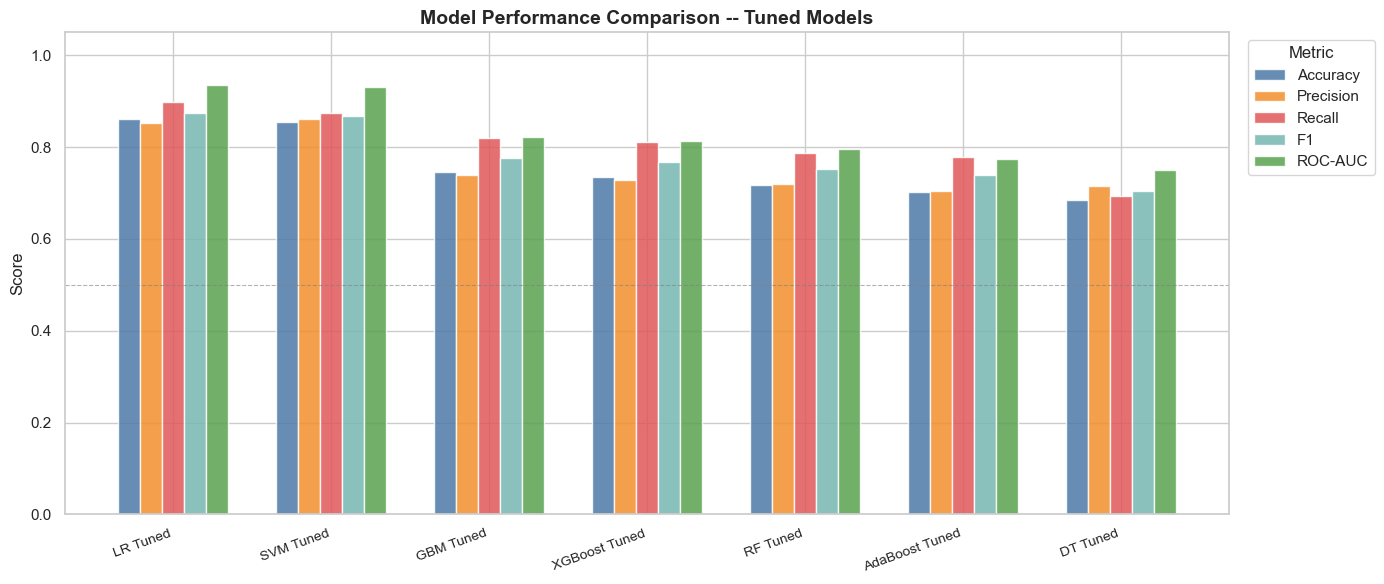

Saved: ..\..\output\eval_metric_comparison_bar.png


In [21]:
# Grouped bar chart: all 5 metrics across all 7 tuned models for visual comparison
try:
    metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
    plot_df = tuned_df.set_index("Model")[metric_cols]
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(plot_df))
    width = 0.14
    colors_bar = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f"]
    for i, (metric, color) in enumerate(zip(metric_cols, colors_bar)):
        ax.bar(x + i * width, plot_df[metric], width, label=metric, color=color, alpha=0.85)
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(plot_df.index, rotation=20, ha="right", fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Model Performance Comparison -- Tuned Models", fontsize=14, fontweight="bold")
    ax.legend(title="Metric", bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.axhline(y=0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    plt.tight_layout()
    save_path = os.path.join(output_dir, "eval_metric_comparison_bar.png")
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
except Exception as e:
    print(f"[ERROR] Metric bar chart failed: {e}")

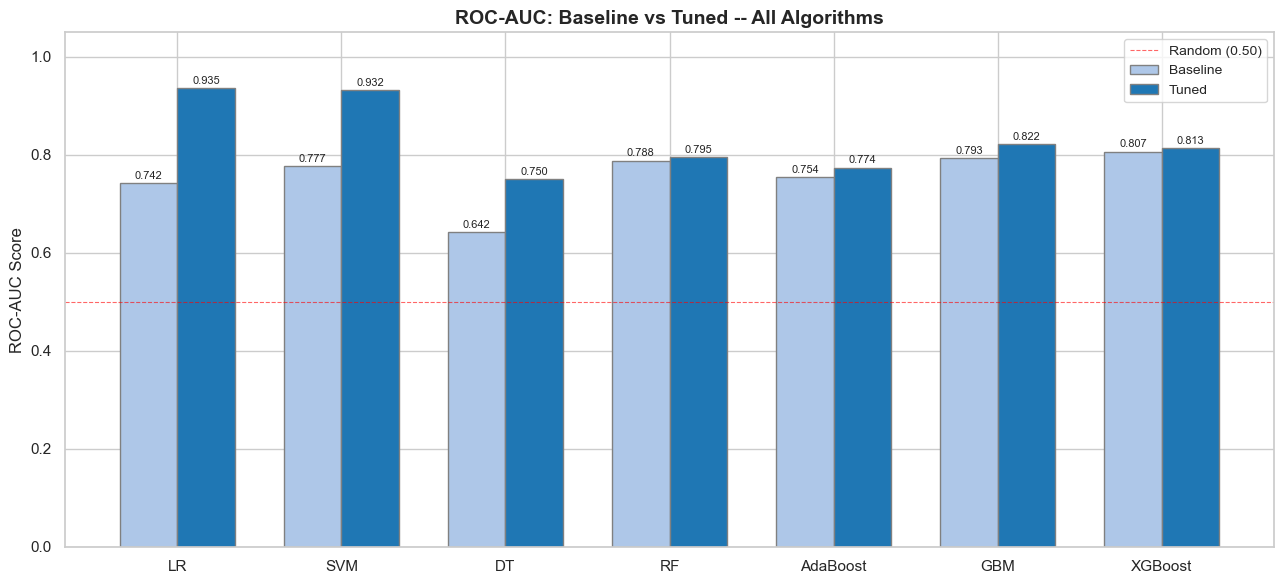

Saved: ..\..\output\eval_roc_auc_baseline_vs_tuned.png


In [22]:
# Side-by-side ROC-AUC bar chart comparing Baseline vs Tuned per algorithm
try:
    algos = ["LR", "SVM", "DT", "RF", "AdaBoost", "GBM", "XGBoost"]
    base_keys_auc  = ["lr_baseline", "svc_baseline", "dt_baseline", "rf_baseline",
                      "ada_baseline", "gbm_baseline", "xgb_baseline"]
    tuned_keys_auc = ["lr_best", "svc_best", "dt_best", "rf_best",
                      "ada_best", "gbm_best", "xgb_best"]

    def get_auc(key):
        row = metrics_df[metrics_df["Model"] == model_display_names[key]]
        return float(row["ROC-AUC"].values[0]) if not row.empty else 0.0

    base_auc  = [get_auc(k) for k in base_keys_auc]
    tuned_auc = [get_auc(k) for k in tuned_keys_auc]

    x = np.arange(len(algos))
    w = 0.35
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar(x - w/2, base_auc,  w, label="Baseline", color="#aec7e8", edgecolor="grey")
    ax.bar(x + w/2, tuned_auc, w, label="Tuned",    color="#1f77b4", edgecolor="grey")
    for i, (b, t) in enumerate(zip(base_auc, tuned_auc)):
        ax.text(x[i] - w/2, b + 0.005, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
        ax.text(x[i] + w/2, t + 0.005, f"{t:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(algos, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.axhline(y=0.5, color="red", linestyle="--", linewidth=0.8, alpha=0.6, label="Random (0.50)")
    ax.set_ylabel("ROC-AUC Score", fontsize=12)
    ax.set_title("ROC-AUC: Baseline vs Tuned -- All Algorithms", fontsize=14, fontweight="bold")
    ax.legend(fontsize=10)
    plt.tight_layout()
    save_path = os.path.join(output_dir, "eval_roc_auc_baseline_vs_tuned.png")
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
except Exception as e:
    print(f"[ERROR] Baseline vs Tuned AUC chart failed: {e}")

In [23]:
print("=" * 60)
print("=== CLASSIFICATION REPORTS -- ALL TUNED MODELS ===")
print("=" * 60)

# Full per-class precision / recall / F1 / support for each tuned model
for key in tuned_keys:
    if key not in all_preds:
        continue
    label = model_display_names[key]
    print(f"\n--- {label} ---")
    print(classification_report(y_test, all_preds[key],
                                target_names=["Down (0)", "Up (1)"]))

=== CLASSIFICATION REPORTS -- ALL TUNED MODELS ===

--- LR Tuned ---
              precision    recall  f1-score   support

    Down (0)       0.87      0.82      0.84      1270
      Up (1)       0.85      0.90      0.87      1500

    accuracy                           0.86      2770
   macro avg       0.86      0.86      0.86      2770
weighted avg       0.86      0.86      0.86      2770


--- SVM Tuned ---
              precision    recall  f1-score   support

    Down (0)       0.85      0.83      0.84      1270
      Up (1)       0.86      0.87      0.87      1500

    accuracy                           0.85      2770
   macro avg       0.85      0.85      0.85      2770
weighted avg       0.85      0.85      0.85      2770


--- DT Tuned ---
              precision    recall  f1-score   support

    Down (0)       0.65      0.68      0.66      1270
      Up (1)       0.72      0.69      0.70      1500

    accuracy                           0.68      2770
   macro avg       0.6

In [24]:
print("=" * 60)
print("=== FINAL SUMMARY ===")
print("=" * 60)

# Identify and display the best model by ROC-AUC among all tuned models
best_row = tuned_df.iloc[0]
print(f"\n  Best Model  : {best_row['Model']}")
print(f"  ROC-AUC    : {best_row['ROC-AUC']:.4f}")
print(f"  Accuracy   : {best_row['Accuracy']:.4f}")
print(f"  Precision  : {best_row['Precision']:.4f}")
print(f"  Recall     : {best_row['Recall']:.4f}")
print(f"  F1         : {best_row['F1']:.4f}")

print("\n  Output files saved to:", os.path.abspath(output_dir))
print("  - eval_confusion_matrices_baseline.png")
print("  - eval_confusion_matrices_tuned.png")
print("  - eval_roc_curves_all_models.png")
print("  - eval_metric_comparison_bar.png")
print("  - eval_roc_auc_baseline_vs_tuned.png")
print("  - eval_model_comparison.csv")

=== FINAL SUMMARY ===

  Best Model  : LR Tuned
  ROC-AUC    : 0.9354
  Accuracy   : 0.8610
  Precision  : 0.8535
  Recall     : 0.8973
  F1         : 0.8749

  Output files saved to: e:\Python_projects\Coursera\Classification-badge\s_n_p_classifier\model_files\output
  - eval_confusion_matrices_baseline.png
  - eval_confusion_matrices_tuned.png
  - eval_roc_curves_all_models.png
  - eval_metric_comparison_bar.png
  - eval_roc_auc_baseline_vs_tuned.png
  - eval_model_comparison.csv


=== STEP 10: FEATURE IMPORTANCE ===


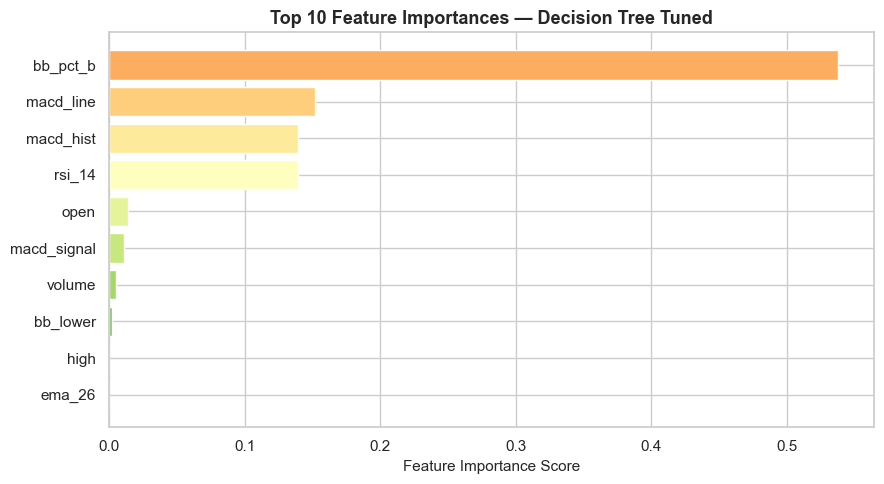

  Saved: ..\..\output\dt_feature_importance.png


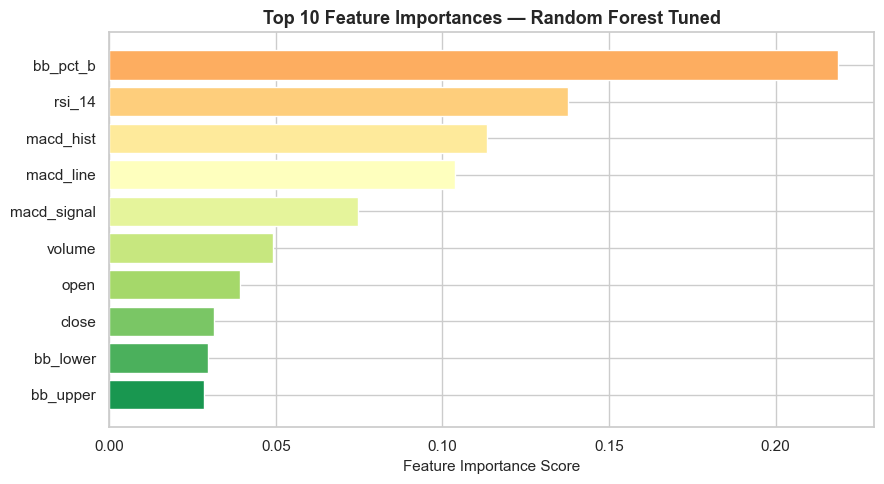

  Saved: ..\..\output\rf_feature_importance.png


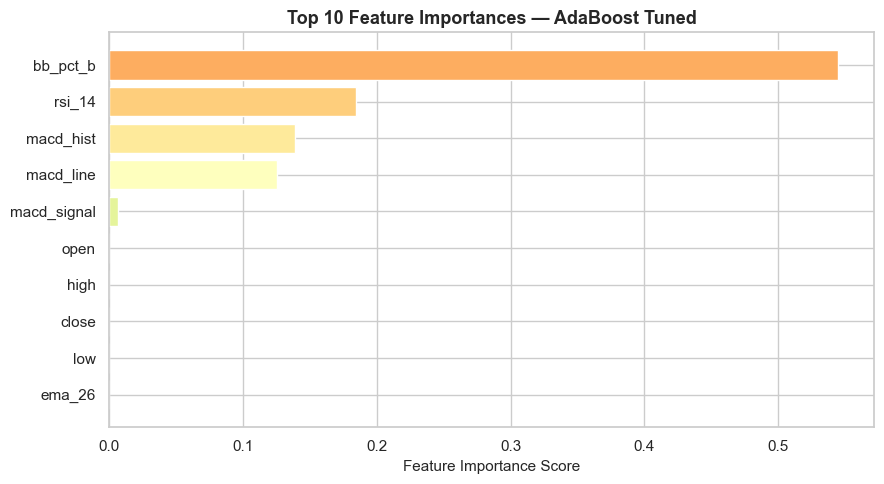

  Saved: ..\..\output\ada_feature_importance.png


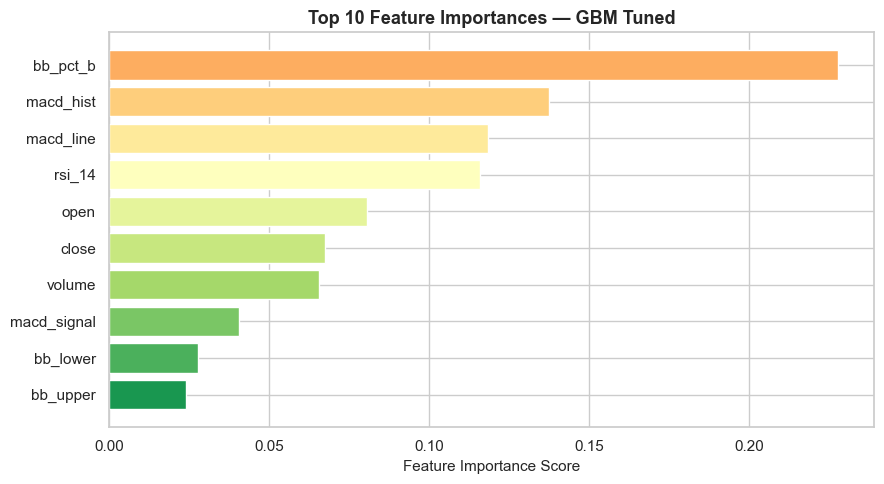

  Saved: ..\..\output\gbm_feature_importance.png


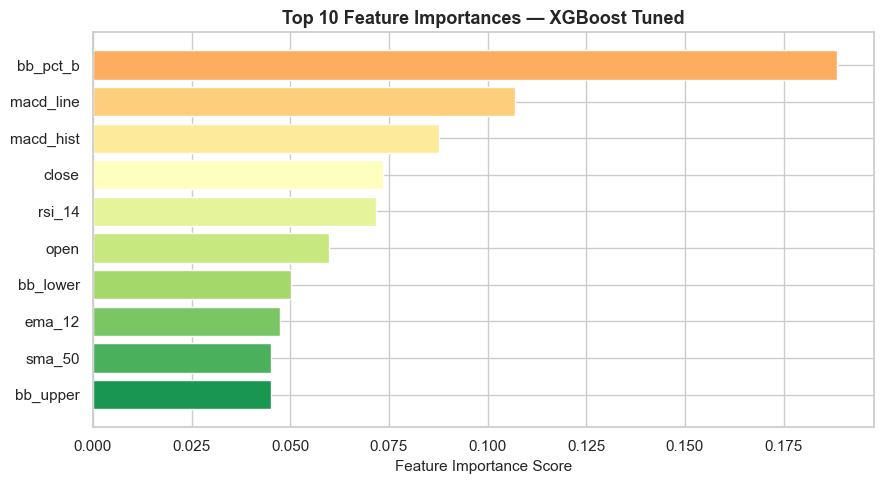

  Saved: ..\..\output\xgb_feature_importance.png


In [25]:
print("=" * 60)
print("=== STEP 10: FEATURE IMPORTANCE ===")
print("=" * 60)

# Tree-based and boosting tuned models that expose feature_importances_
tree_boosting_models = {
    "dt_best"  : "Decision Tree Tuned",
    "rf_best"  : "Random Forest Tuned",
    "ada_best" : "AdaBoost Tuned",
    "gbm_best" : "GBM Tuned",
    "xgb_best" : "XGBoost Tuned",
}

feature_names = X_train.columns.tolist()

for model_key, label in tree_boosting_models.items():
    if model_key not in models:
        print(f"  [SKIP] {model_key} not loaded.")
        continue
    try:
        model      = models[model_key]
        importances = model.feature_importances_
        fi_series  = (
            pd.Series(importances, index=feature_names)
            .sort_values(ascending=False)
            .head(10)
        )

        fig, ax = plt.subplots(figsize=(9, 5))
        bar_colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(fi_series)))
        ax.barh(fi_series.index[::-1], fi_series.values[::-1], color=bar_colors[::-1])
        ax.set_xlabel("Feature Importance Score", fontsize=11)
        ax.set_title(f"Top 10 Feature Importances — {label}", fontsize=13, fontweight="bold")
        plt.tight_layout()

        fname     = model_key.replace("_best", "") + "_feature_importance.png"
        save_path = os.path.join(output_dir, fname)
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        plt.show()
        print(f"  Saved: {save_path}")
    except Exception as e:
        print(f"  [ERROR] {model_key}: {e}")

In [26]:
print("=" * 60)
print("=== STEP 11: OVERFITTING CHECK ===")
print("=" * 60)

OVERFIT_THRESHOLD = 0.05

tuned_model_keys = {
    "lr_best"  : "LR Tuned",
    "svc_best" : "SVM Tuned",
    "dt_best"  : "DT Tuned",
    "rf_best"  : "RF Tuned",
    "ada_best" : "AdaBoost Tuned",
    "gbm_best" : "GBM Tuned",
    "xgb_best" : "XGBoost Tuned",
}

overfit_rows = []

for model_key, label in tuned_model_keys.items():
    if model_key not in models:
        print(f"  [SKIP] {model_key} not loaded.")
        continue
    try:
        model = models[model_key]

        # Training metrics
        y_train_pred = model.predict(X_train)
        train_acc    = accuracy_score(y_train, y_train_pred)
        train_auc    = (
            roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
            if hasattr(model, "predict_proba") else None
        )

        # Test metrics
        y_test_pred = model.predict(X_test)
        test_acc    = accuracy_score(y_test, y_test_pred)
        test_auc    = (
            roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
            if hasattr(model, "predict_proba") else None
        )

        acc_gap     = round(train_acc - test_acc, 4)
        auc_gap     = round(train_auc - test_auc, 4) if (train_auc and test_auc) else None
        overfit_flag = (
            "POTENTIALLY OVERFIT" if auc_gap is not None and auc_gap > OVERFIT_THRESHOLD
            else "OK"
        )

        overfit_rows.append({
            "Model"     : label,
            "Train Acc" : round(train_acc, 4),
            "Test Acc"  : round(test_acc, 4),
            "Acc Gap"   : acc_gap,
            "Train AUC" : round(train_auc, 4) if train_auc is not None else None,
            "Test AUC"  : round(test_auc, 4)  if test_auc  is not None else None,
            "AUC Gap"   : auc_gap,
            "Status"    : overfit_flag,
        })

        auc_str = f"{auc_gap:.4f}" if auc_gap is not None else "N/A"
        if overfit_flag != "OK":
            print(f"  [WARNING] {label:<22} AUC Gap = {auc_str}  → {overfit_flag}")
        else:
            print(f"  {label:<22} AUC Gap = {auc_str}  ({overfit_flag})")

    except Exception as e:
        print(f"  [ERROR] {model_key}: {e}")

overfit_df = pd.DataFrame(overfit_rows)
display(
    overfit_df.style
    .format({
        "Train Acc": "{:.4f}", "Test Acc": "{:.4f}", "Acc Gap": "{:+.4f}",
        "Train AUC": "{:.4f}", "Test AUC": "{:.4f}", "AUC Gap": "{:+.4f}",
    }, na_rep="N/A")
    .set_caption(
        f"Overfitting Check — Tuned Models  (flag if AUC gap > {OVERFIT_THRESHOLD})"
    )
)

=== STEP 11: OVERFITTING CHECK ===
  LR Tuned               AUC Gap = -0.0009  (OK)
  SVM Tuned              AUC Gap = 0.0050  (OK)
  DT Tuned               AUC Gap = 0.0464  (OK)
  [WARNING] RF Tuned               AUC Gap = 0.1928  → POTENTIALLY OVERFIT
  AdaBoost Tuned         AUC Gap = 0.0286  (OK)
  [WARNING] GBM Tuned              AUC Gap = 0.1785  → POTENTIALLY OVERFIT
  [WARNING] XGBoost Tuned          AUC Gap = 0.1034  → POTENTIALLY OVERFIT


,Model,Train Acc,Test Acc,Acc Gap,Train AUC,Test AUC,AUC Gap,Status
0,LR Tuned,0.8682,0.8610,+0.0072,0.9345,0.9354,-0.0009,OK
1,SVM Tuned,0.8650,0.8549,+0.0101,0.9366,0.9316,+0.0050,OK
2,DT Tuned,0.7121,0.6848,+0.0273,0.7962,0.7498,+0.0464,OK
3,RF Tuned,0.9391,0.7184,+0.2207,0.9878,0.7950,+0.1928,POTENTIALLY OVERFIT
4,AdaBoost Tuned,0.7255,0.7025,+0.0230,0.8022,0.7736,+0.0286,OK
5,GBM Tuned,1.0000,0.7455,+0.2545,1.0000,0.8215,+0.1785,POTENTIALLY OVERFIT
6,XGBoost Tuned,0.8350,0.7339,+0.1011,0.9167,0.8133,+0.1034,POTENTIALLY OVERFIT


In [27]:
print("=" * 60)
print("=== STEP 12: SAVE BEST MODEL ===")
print("=" * 60)

from sklearn.preprocessing import MinMaxScaler

# tuned_df is already sorted by ROC-AUC descending — first row is the best model
best_display_label = tuned_df.iloc[0]["Model"]
best_roc_auc       = tuned_df.iloc[0]["ROC-AUC"]

# Reverse-lookup: display label → model key
display_to_key = {v: k for k, v in model_display_names.items()}
best_model_key = display_to_key[best_display_label]
best_model_obj = models[best_model_key]

print(f"  Best model   : {best_display_label}  (key: {best_model_key})")
print(f"  Test ROC-AUC : {best_roc_auc:.4f}")

# Save best model as best_model.pkl
best_model_path = os.path.join(output_dir, "best_model.pkl")
joblib.dump(best_model_obj, best_model_path)
print(f"\n  Saved best model  → {os.path.abspath(best_model_path)}")

# Re-fit MinMaxScaler on X_train (mirrors the scaler applied in 03_feature_engineer.ipynb)
# The original scaler was not persisted; re-fitting on the same X_train is equivalent.
scaler = MinMaxScaler()
scaler.fit(X_train)
scaler_path = os.path.join(output_dir, "scaler.pkl")
joblib.dump(scaler, scaler_path)
print(f"  Saved scaler      → {os.path.abspath(scaler_path)}")

print("\n  Both artifacts are ready for inference / deployment.")

=== STEP 12: SAVE BEST MODEL ===
  Best model   : LR Tuned  (key: lr_best)
  Test ROC-AUC : 0.9354

  Saved best model  → e:\Python_projects\Coursera\Classification-badge\s_n_p_classifier\model_files\output\best_model.pkl
  Saved scaler      → e:\Python_projects\Coursera\Classification-badge\s_n_p_classifier\model_files\output\scaler.pkl

  Both artifacts are ready for inference / deployment.
